# Part II - Ford GoBike System Data Explanatory Analysis
## by Debasis Mishra


## Investigation Overview


> The goal of this presentation is to explore rider behavior and usage patterns within the Ford GoBike bike-sharing system using trip data collected in February 2019. The analysis focuses on understanding how riders use the service, identifying differences between Customers and Subscribers, and examining how trip characteristics vary across time and demographic groups.

> Through exploratory and explanatory visualizations, the presentation aims to answer key questions related to trip duration, rider demographics, user types, and commuting behavior. The findings provide insights into how the bike-sharing system serves different categories of users and when demand for the service is highest.


## Dataset Overview

> The Ford GoBike System Data dataset contains information about individual bike-sharing trips made throughout the San Francisco Bay Area during February 2019. Each row in the dataset represents a single bike trip and includes details such as trip duration, trip start and end times, station information, rider demographics, and subscription status.

> Key variables used in this analysis include:

> duration_sec: Length of the trip in seconds.
start_time and end_time: Timestamps indicating when a trip began and ended.
user_type: Identifies whether the rider is a Customer or Subscriber.
member_gender: Rider gender.
member_birth_year: Rider birth year, used to calculate age.
start_station_name and end_station_name: Bike station locations.

> Additional features such as age, hour of day, and day of week were derived during the data preparation process to support the analysis of rider demographics and temporal usage patterns.

>The dataset provides a valuable opportunity to examine how different groups of riders use the bike-sharing system and to identify trends that can help explain overall travel behavior.

In [1]:
# import all packages and set plots to be embedded inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb

%matplotlib inline

# suppress warnings from final output
import warnings
warnings.simplefilter("ignore")

In [2]:
# load in the dataset into a pandas dataframe
# Load Ford GoBike dataset
df = pd.read_csv(
    r'C:\Users\debasis.b.mishra\OneDrive - Accenture\Desktop\Python-Example\Project\201902-fordgobike-tripdata.csv.crdownload'
)
df.head()

,duration_sec,start_time,end_time,start_station_id,start_station_name,start_station_latitude,start_station_longitude,end_station_id,end_station_name,end_station_latitude,end_station_longitude,bike_id,user_type,member_birth_year,member_gender,bike_share_for_all_trip
0,52185,2019-02-28 17:32:10.1450,2019-03-01 08:01:55.9750,21.0,Montgomery St BART Station (Market St at 2nd St),37.789625,-122.400811,13.0,Commercial St at Montgomery St,37.794231,-122.402923,4902,Customer,1984.0,Male,No
1,42521,2019-02-28 18:53:21.7890,2019-03-01 06:42:03.0560,23.0,The Embarcadero at Steuart St,37.791464,-122.391034,81.0,Berry St at 4th St,37.775880,-122.393170,2535,Customer,NaN,NaN,No
2,61854,2019-02-28 12:13:13.2180,2019-03-01 05:24:08.1460,86.0,Market St at Dolores St,37.769305,-122.426826,3.0,Powell St BART Station (Market St at 4th St),37.786375,-122.404904,5905,Customer,1972.0,Male,No
3,36490,2019-02-28 17:54:26.0100,2019-03-01 04:02:36.8420,375.0,Grove St at Masonic Ave,37.774836,-122.446546,70.0,Central Ave at Fell St,37.773311,-122.444293,6638,Subscriber,1989.0,Other,No
4,1585,2019-02-28 23:54:18.5490,2019-03-01 00:20:44.0740,7.0,Frank H Ogawa Plaza,37.804562,-122.271738,222.0,10th Ave at E 15th St,37.792714,-122.248780,4898,Subscriber,1974.0,Male,Yes


## (Visualization 1)

> The Ford GoBike system is primarily used by Subscribers, who account for the vast majority of trips recorded in the dataset. This suggests that the service functions largely as a regular transportation option rather than an occasional recreational service. Understanding the distribution of user types provides important context for interpreting the differences in riding patterns observed throughout the remainder of the analysis.

> Key Insight: Subscribers represent the dominant user group, indicating that most trips are made by riders who use the service on a recurring basis.

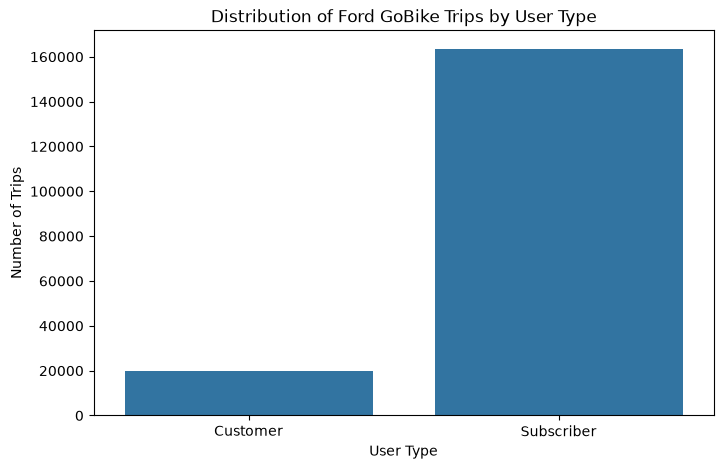

In [4]:
# Count of trips by user type

plt.figure(figsize=(8,5))

base_color = sb.color_palette()[0]

sb.countplot(
    data=df,
    x='user_type',
    color=base_color
)

plt.title('Distribution of Ford GoBike Trips by User Type')
plt.xlabel('User Type')
plt.ylabel('Number of Trips')

plt.show()

## Observation

> Subscribers account for the majority of trips in the dataset, while Customers make up a much smaller share. This suggests that the bike-sharing system is primarily used by regular members who rely on the service for frequent transportation needs.

## (Visualization 2)

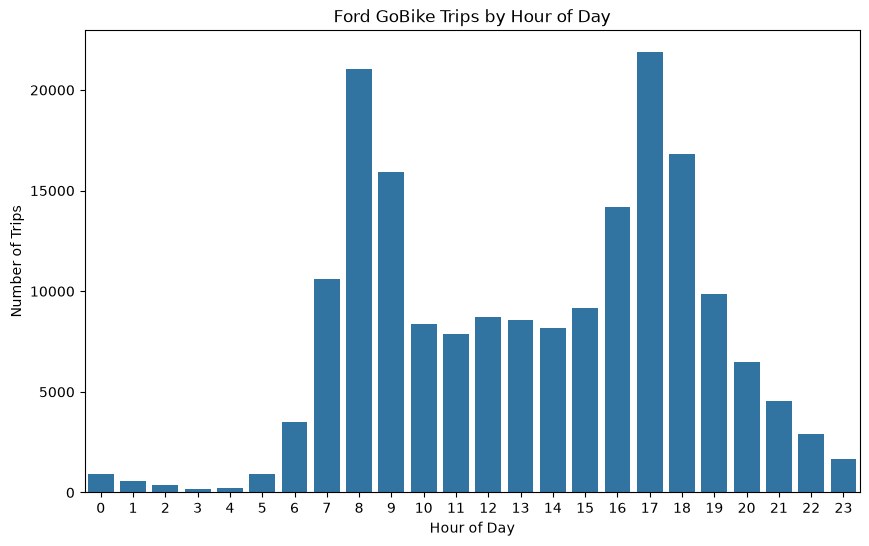

In [7]:
# Number of trips by hour of day

df['start_time'] = pd.to_datetime(df['start_time'])
df['start_hour'] = df['start_time'].dt.hour

plt.figure(figsize=(10,6))

base_color = sb.color_palette()[0]

sb.countplot(
    data=df,
    x='start_hour',
    color=base_color
)

plt.title('Ford GoBike Trips by Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Trips')

plt.show()

## Observation

> Trip activity reaches its highest levels during the morning (around 8 AM) and evening (around 5 PM) commuting periods. Usage is substantially lower during late-night hours, providing strong evidence that many riders use the bike-sharing system for daily transportation to and from work.

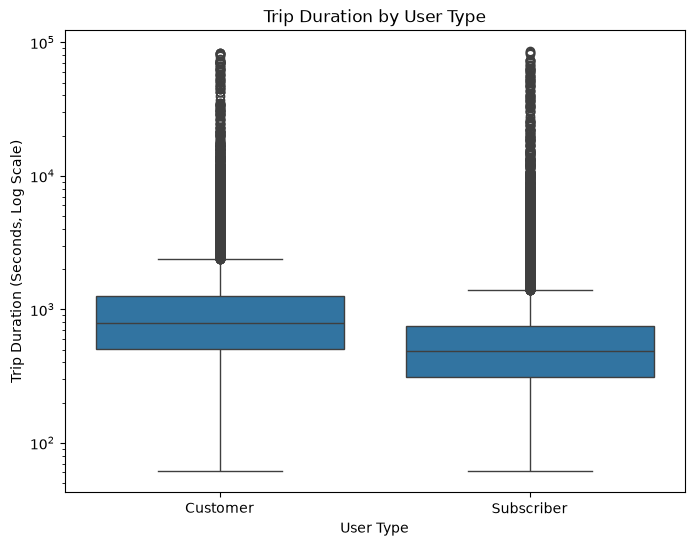

In [8]:
# Trip duration by user type

plt.figure(figsize=(8,6))

sb.boxplot(
    data=df,
    x='user_type',
    y='duration_sec'
)

plt.yscale('log')

plt.title('Trip Duration by User Type')
plt.xlabel('User Type')
plt.ylabel('Trip Duration (Seconds, Log Scale)')

plt.show()

## Observation

> Customers generally have longer trip durations and greater variability in ride length compared to Subscribers. This suggests that Subscribers primarily use the service for shorter transportation-oriented trips, while Customers are more likely to engage in leisure or recreational riding.

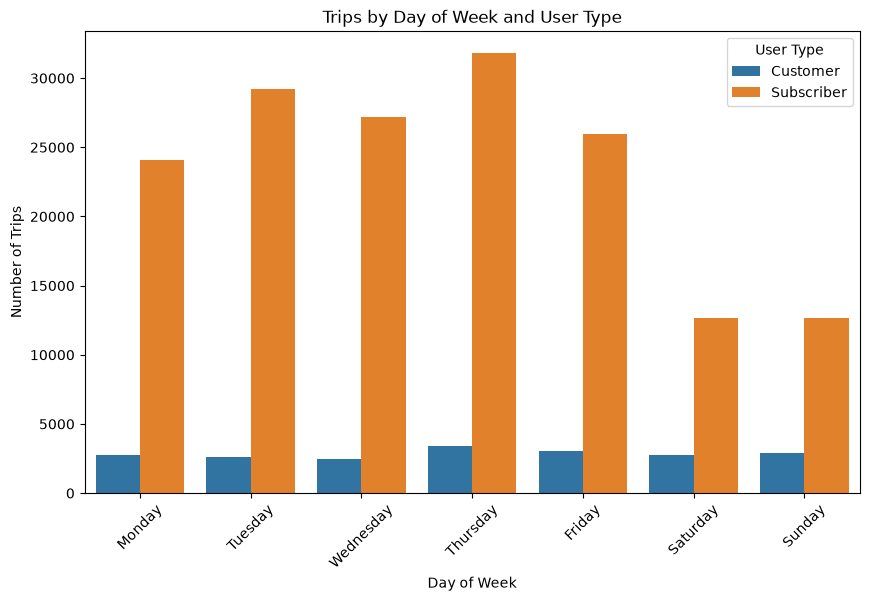

In [9]:
# Create day-of-week column if not already present
df['start_time'] = pd.to_datetime(df['start_time'])
df['start_day'] = df['start_time'].dt.day_name()

day_order = [
    'Monday',
    'Tuesday',
    'Wednesday',
    'Thursday',
    'Friday',
    'Saturday',
    'Sunday'
]

plt.figure(figsize=(10,6))

sb.countplot(
    data=df,
    x='start_day',
    hue='user_type',
    order=day_order
)

plt.title('Trips by Day of Week and User Type')
plt.xlabel('Day of Week')
plt.ylabel('Number of Trips')
plt.xticks(rotation=45)
plt.legend(title='User Type')

plt.show()

## Observation

> Subscriber trips are heavily concentrated during weekdays, particularly from Monday through Friday. Customer trips represent a larger proportion of rides during weekends. This pattern reinforces the conclusion that Subscribers primarily use the system for commuting, whereas Customers are more likely to use it for leisure and recreational purposes.

>**Generate Slideshow**: Once you're ready to generate your slideshow, use the `jupyter nbconvert` command to generate the HTML slide show. . From the terminal or command line, use the following expression.

In [ ]:
!jupyter nbconvert Part_II_slide_deck_template.ipynb --to slides --post serve